<a href="https://colab.research.google.com/github/karol-duda/dss_thesis_aml_shap/blob/main/notebooks/01_eda_sprint1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 1: Exploratory Data Analysis (EDA) & Feature Engineering Strategy
**Author:** Karol Duda  
**Project:** Measuring and Controlling SHAP Explanation Instability in High-Stakes AML Systems

## Executive Summary
This notebook executes the initial data exploration and pre-processing strategy for the IEEE-CIS Fraud Detection dataset. It covers:
1. **Data Quality Assessment:** Addressing massive sparsity and informative missingness.
2. **Risk Identification:** Highlighting class imbalance and extreme multicollinearity (the driver of the Rashomon Effect).
3. **Temporal Analysis:** Visualizing the sequential nature of transactions to inform validation strategies.
4. **Entity Resolution (The "Magic" Features):** Implementing behavioral context features based on state-of-the-art Kaggle methodologies.

In [ ]:
# 1. SETUP & IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("muted")

Mounted at /content/drive


In [ ]:
# 2. DATA TYPES DEFINITION (Memory Optimization)
dtypes = {
    'TransactionID': 'int32',
    'isFraud': 'int8',
    'TransactionDT': 'int32',
    'TransactionAmt': 'float32',
    'ProductCD': 'category',
    'card1': 'int16', 'card2': 'float32', 'card3': 'float32', 'card4': 'category', 'card5': 'float32', 'card6': 'category',
    'addr1': 'float32', 'addr2': 'float32',
    'dist1': 'float32', 'dist2': 'float32',
    'P_emaildomain': 'category', 'R_emaildomain': 'category',
}
# Downcast C, D, M, and selected V columns to float32
for i in range(1, 15): dtypes[f'C{i}'] = 'float32'
for i in range(1, 16): dtypes[f'D{i}'] = 'float32'
for i in range(1, 10): dtypes[f'M{i}'] = 'category'

v_cols = [1, 3, 4, 6, 8, 11, 13, 14, 17, 20, 23, 26, 27, 30, 36, 37, 40, 41, 44, 47, 48] + list(range(54, 340))
for i in v_cols: dtypes[f'V{i}'] = 'float32'

print("Data types mapped for memory optimization.")

Data types mapped for memory optimization.


In [ ]:
# 3. LOADING DATA
path = '/content/drive/MyDrive/'

print("Loading datasets...")
train = pd.read_csv(f'{path}train_transaction.csv', dtype=dtypes, index_col='TransactionID')
identity = pd.read_csv(f'{path}train_identity.csv', index_col='TransactionID')

print("Merging transaction and identity data...")
train = train.merge(identity, how='left', left_index=True, right_index=True)

del identity
gc.collect()

print(f"Data Loaded Successfully. Shape: {train.shape}")

Loading datasets...
Merging transaction and identity data...
Data Loaded Successfully. Shape: (590540, 433)


## 1. General Data Overview
First, we inspect the structural integrity of the dataset, looking at the distribution of missing values across the 400+ features.

In [ ]:

# Data Inspection
print("--- FIRST 5 ROWS ---")
display(train.head())

print("\n--- MISSING VALUES PERCENTAGE (>50%) ---")
missing_percent = (train.isnull().sum() / len(train)) * 100
print(missing_percent[missing_percent > 50].sort_values(ascending=False).head(15))

--- FIRST 5 ROWS ---


,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M



--- MISSING VALUES PERCENTAGE (>50%) ---
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_22    99.124699
id_23    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
dtype: float64


## 2. Risk Assessment: Class Imbalance
The target variable `isFraud` is highly imbalanced.



**Methodological Implication:** The decision boundary will be supported by very few positive instances. This inherent instability forces us to:
1. Evaluate using **PR-AUC** instead of ROC-AUC.
2. Use a weighted loss function during model training.

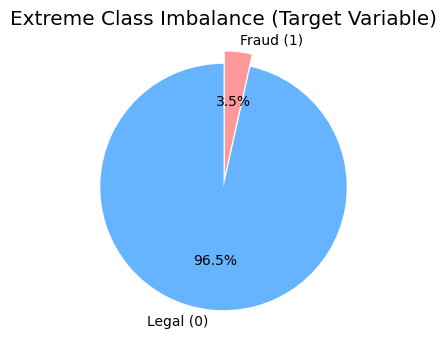

In [ ]:
plt.figure(figsize=(6, 4))
train['isFraud'].value_counts(normalize=True).plot.pie(
    autopct='%.1f%%',
    labels=['Legal (0)', 'Fraud (1)'],
    colors=['#66b3ff', '#ff9999'],
    startangle=90,
    explode=(0, 0.1)
)
plt.title("Extreme Class Imbalance (Target Variable)")
plt.ylabel("")
plt.show()

## 3. Data Quality: Informative Missingness
Many features contain massive amounts of missing data (NaNs). However, in the context of tabular financial data, this missingness carries semantic meaning.

* `dist1` (~60% missing): Suggests digital goods where physical distance is irrelevant.
* `R_emaildomain` (~77% missing): Typical for standard B2C merchant transactions.

**Methodological Implication:** Dropping rows or imputing means would destroy this signal. Tree-based models (XGBoost/LightGBM) will be used to natively route `NaN` values.

/tmp/ipython-input-177/2706534147.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=missing_real.index, y=missing_real.values, palette='Reds_r')


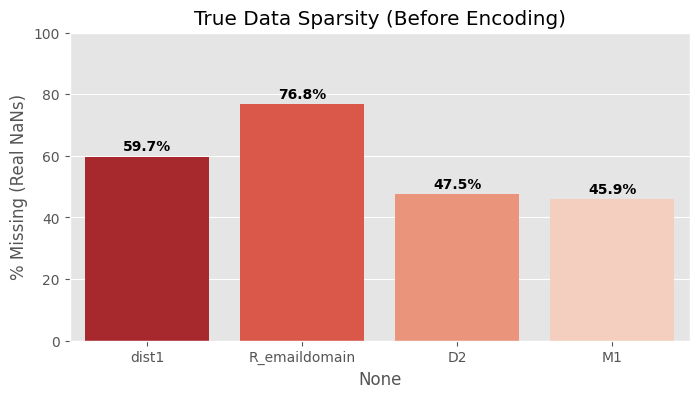

165

In [ ]:
# Check raw missingness for key behavioral/identity columns
raw_check = pd.read_csv(f'{path}train_transaction.csv', usecols=['M1', 'R_emaildomain', 'dist1', 'D2'])
missing_real = raw_check.isnull().mean() * 100

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=missing_real.index, y=missing_real.values, palette='Reds_r')
plt.ylabel('% Missing (Real NaNs)')
plt.title('True Data Sparsity (Before Encoding)')
plt.ylim(0, 100)

for i, v in enumerate(missing_real.values):
    ax.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()

del raw_check; gc.collect()

## 4. Multicollinearity & The Rashomon Effect
Vesta-engineered features (V-columns) represent the bulk of the dataset.



[Image of Multicollinearity correlation matrix]


**Methodological Implication:** Extreme correlation (e.g., `V307` and `V308`) causes the model to arbitrarily select features during training. This is the root cause of **SHAP Explanation Instability (RQ1)**, justifying the need for Seed Ensembling (RQ3).

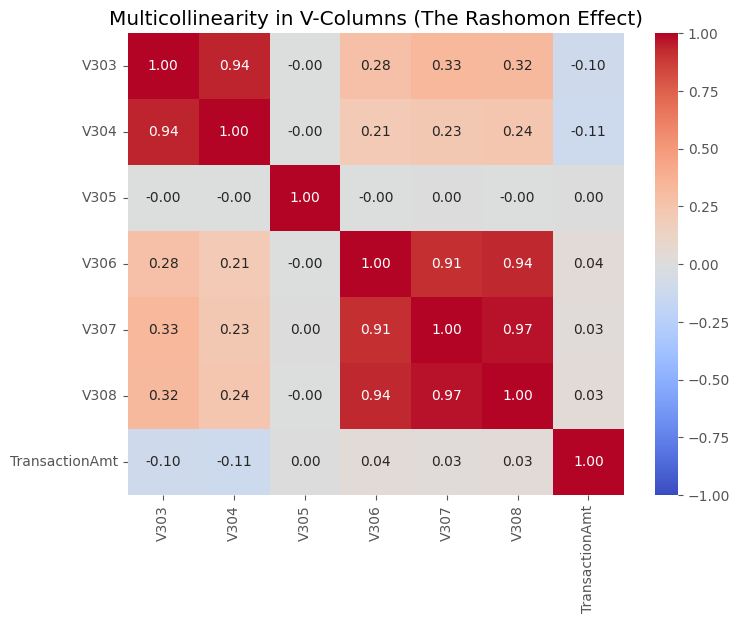

8152

In [ ]:
# Convert categories to codes temporarily for correlation
train_encoded = train.copy()
for c in train_encoded.columns:
    if train_encoded[c].dtype.name == 'category':
        train_encoded[c] = pd.factorize(train_encoded[c])[0]

corr_features = ['V303','V304','V305','V306','V307', 'V308', 'TransactionAmt']
plt.figure(figsize=(8,6))
sns.heatmap(train_encoded[corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Multicollinearity in V-Columns (The Rashomon Effect)")
plt.show()

del train_encoded; gc.collect()

## 5. Temporal Leakage Risk
Transactions occur strictly sequentially.



**Methodological Implication:** We must implement a strict **Time-Series Split** (75% Train / 25% Validation) rather than random K-Fold validation to prevent Look-Ahead Bias.

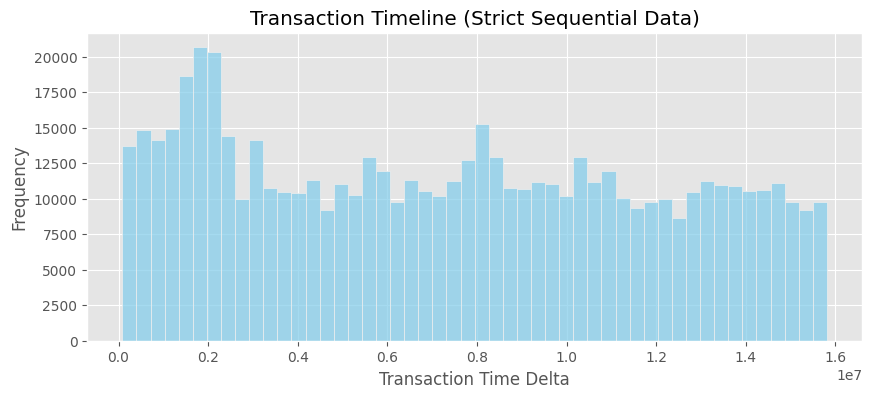

In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(train['TransactionDT'], bins=50, kde=False, color='skyblue')
plt.title("Transaction Timeline (Strict Sequential Data)")
plt.xlabel("Transaction Time Delta")
plt.ylabel("Frequency")
plt.show()

## 6. Feature Engineering: SOTA Entity Resolution (The "Magic")
Based on state-of-the-art literature and leading solutions, the baseline dataset lacks historical user context.



**Strategy:**
1. **Recoding:** Create a `UID` mapping by combining `card1`, `addr1`, and a normalized time-delta (`D1`).
2. **Aggregation:** Generate behavioral features (e.g., standard deviation of transaction amount per UID).
3. **Anti-Overfitting:** Drop the `UID` itself so the model learns the *pattern*, not the specific *user*.

In [ ]:
print("Executing Entity Resolution (UID Generation)...")

# 1. Normalize Time Delta Columns
for i in range(1,16):
    if i in [1,2,3,5,9]: continue
    col = f'D{i}'
    if col in train.columns:
        train[col] = train[col] - train.TransactionDT / np.float32(24*60*60)

# 2. Create UID (Card + Address + Start Day)
train['day'] = train.TransactionDT / (24*60*60)
train['uid'] = train['card1'].astype(str) + '_' + train['addr1'].astype(str) + '_' + np.floor(train.day - train.D1).astype(str)

print(f"Unique entities (UIDs) resolved: {train['uid'].nunique()}")

# Helper Functions for Aggregation
def encode_FE(df, cols):
    for col in cols:
        df[col+'_FE'] = df[col].map(df[col].value_counts(normalize=True)).astype('float32')

def encode_AG(main_columns, uids, aggregations=['mean', 'std'], df=None):
    for main_column in main_columns:
        for col in uids:
            for agg_type in aggregations:
                new_col_name = f"{main_column}_{col}_{agg_type}"
                temp_df = df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(columns={agg_type: new_col_name})
                temp_df.index = list(temp_df[col])
                temp_df = temp_df[new_col_name].to_dict()
                df[new_col_name] = df[col].map(temp_df).astype('float32')

# 3. Apply Contextual Aggregations
print("Generating behavioral statistics per UID...")
encode_FE(train, ['card1', 'addr1', 'P_emaildomain'])
encode_AG(['TransactionAmt', 'D9', 'D11'], ['uid'], ['mean', 'std'], train)

# 4. Clean up
train.drop(['uid', 'day'], axis=1, inplace=True)
gc.collect()

print("Feature Engineering Complete. Dataset is ready for baseline modeling (Sprint 3).")

Executing Entity Resolution (UID Generation)...
Unique entities (UIDs) resolved: 217850
Generating behavioral statistics per UID...
Feature Engineering Complete. Dataset is ready for baseline modeling (Sprint 3).


## 7. Artifact Generation (Data Checkpointing)
**Objective:** Decouple the Exploratory Data Analysis (EDA) and Feature Engineering pipeline from the predictive modeling phase (Sprint 3).

**Implementation:** The fully processed dataset, including the engineered behavioral features, is serialized and exported to Google Drive.

**Why Parquet instead of CSV?**
* **Type Preservation:** Unlike CSV, the Parquet format perfectly retains the memory-optimized data types (`float32`, `category`) defined at the beginning of this notebook.
* **I/O Efficiency:** Parquet is a columnar storage format, which drastically reduces disk footprint and loading times for the subsequent modeling notebooks, preventing memory (RAM) exhaustion in the cloud environment.

In [11]:
# 7. EXPORT PROCESSED DATA
import pyarrow as pa
import pyarrow.parquet as pq

path = '/content/drive/MyDrive/'
print("Exporting processed dataset to Parquet format...")

# Zapisanie zbioru jako nowy plik (nie nadpisuje starych danych!)
train.to_parquet(f'{path}train_processed.parquet', engine='pyarrow')

print("Artifact successfully saved: 'train_processed.parquet'.")
print("Sprint 1 Pipeline Complete. Ready for Sprint 3 (Modeling).")

Exporting processed dataset to Parquet format...
Artifact successfully saved: 'train_processed.parquet'.
Sprint 1 Pipeline Complete. Ready for Sprint 3 (Modeling).
